# 🔐 RBAC (Role-Based Access Control) with LangGraph + ChromaDB

This notebook demonstrates how to build a **document-level RBAC system** using:
- **ChromaDB** — vector store with metadata filtering
- **LangGraph** — stateful workflow (authenticate → retrieve → generate)
- **LangChain** — LLM chain & retriever abstraction

## 🗂️ Access Control Design

| Document | Topic | Allowed Group |
|----------|-------|---------------|
| Doc 1 | Q1 Financial Report | `finance_team` |
| Doc 2 | Budget Planning 2025 | `finance_team` |
| Doc 3 | Revenue Forecast | `finance_team` |
| Doc 4 | Employee Handbook | `hr_team` |
| Doc 5 | Hiring & Onboarding Policy | `hr_team` |

| Email | Role | Can Access |
|-------|------|------------|
| `muadh@company.com` | `finance_team` | Docs 1, 2, 3 |
| `vedanth@company.com` | `hr_team` | Docs 4, 5 |
| `ravi@company.com` | `admin` | All Docs |

## 📦 Step 1: Install Dependencies

In [1]:
!pip install -qU \
    langchain \
    langchain-community \
    langchain-openai \
    langgraph \
    chromadb \
    sentence-transformers \
    python-dotenv

## 🔑 Step 2: Configure API Key

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

# Set your OpenAI API key here (or via .env file)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "sk-YOUR-KEY-HERE")

print(" Environment configured")

 Environment configured


## 📚 Step 3: Define the 5 Documents with Access Metadata

Each document is tagged with an `access_group` in its metadata.
ChromaDB will use this for **server-side filtering** at retrieval time.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("reports/q1_financial_report.pdf")
pages = loader.load()  # returns list of Documents (one per page)

# Inject RBAC metadata into every page
for page in pages:
    page.metadata.update({
        "doc_id": "doc_1",
        "title": "Q1 Financial Report 2025",
        "access_group": "finance_team",
        "category": "finance"
    })

documents.extend(pages)

In [ ]:
from langchain_community.document_loaders import Docx2txtLoader

loader = Docx2txtLoader("hr/employee_handbook.docx")
docs = loader.load()

for doc in docs:
    doc.metadata.update({
        "doc_id": "doc_4",
        "title": "Employee Handbook 2025",
        "access_group": "hr_team",
        "category": "hr"
    })

documents.extend(docs)

In [ ]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

# RBAC config — maps filename pattern → metadata
RBAC_CONFIG = {
    "finance/": {"access_group": "finance_team", "category": "finance"},
    "hr/":      {"access_group": "hr_team",      "category": "hr"},
}

all_documents = []

for folder, meta in RBAC_CONFIG.items():
    loader = DirectoryLoader(folder, glob="**/*.pdf", loader_cls=PyPDFLoader)
    docs = loader.load()
    
    for doc in docs:
        doc.metadata.update(meta)  # ← attach RBAC metadata
    
    all_documents.extend(docs)
    print(f"Loaded {len(docs)} pages from '{folder}' → group: {meta['access_group']}")

File on disk  →  Loader  →  Document(page_content, metadata={})
                                                        
                               You inject access_group here AFTER loading

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

loader = PyPDFLoader("finance/budget_2025.pdf")
pages  = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks   = splitter.split_documents(pages)

# Metadata flows into every chunk automatically from the parent doc
# Just make sure you set it on the pages BEFORE splitting
for page in pages:
    page.metadata["access_group"] = "finance_team"

chunks = splitter.split_documents(pages)
#  Every chunk now carries access_group = "finance_team"

In [3]:
from langchain_core.documents import Document

# ── 5 Sample Documents ──────────────────────────────────────────────────────
documents = [
    Document(
        page_content="""
        Q1 Financial Report 2025: Total revenue reached $4.2M, up 18% YoY.
        Operating expenses were $2.1M. Net profit margin stood at 34%.
        Key growth areas: SaaS subscriptions (+40%) and professional services (+22%).
        """,
        metadata={
            "doc_id": "doc_1",
            "title": "Q1 Financial Report 2025",
            "access_group": "finance_team",
            "category": "finance"
        }
    ),
    Document(
        page_content="""
        Budget Planning 2025: Annual budget allocation totals $18M.
        Engineering: $7M (39%), Sales & Marketing: $5M (28%), HR: $3M (17%),
        Operations: $2M (11%), R&D: $1M (5%). Cost optimization targets 12% reduction
        in cloud infrastructure costs through reserved instances.
        """,
        metadata={
            "doc_id": "doc_2",
            "title": "Budget Planning 2025",
            "access_group": "finance_team",
            "category": "finance"
        }
    ),
    Document(
        page_content="""
        Revenue Forecast Q2-Q4 2025: Projected ARR of $19.5M by year-end.
        Enterprise segment expected to contribute 60% of new ARR.
        Churn rate forecast: 4.2%. New logo target: 85 enterprise accounts.
        Pipeline coverage ratio stands at 3.2x for remaining quarters.
        """,
        metadata={
            "doc_id": "doc_3",
            "title": "Revenue Forecast 2025",
            "access_group": "finance_team",
            "category": "finance"
        }
    ),
    Document(
        page_content="""
        Employee Handbook 2025: All employees must adhere to the code of conduct.
        Working hours are flexible (core hours 10am–3pm). Remote work policy allows
        up to 3 days WFH per week. Annual leave: 25 days. Health insurance covers
        employee + family. Performance reviews are bi-annual (June & December).
        """,
        metadata={
            "doc_id": "doc_4",
            "title": "Employee Handbook 2025",
            "access_group": "hr_team",
            "category": "hr"
        }
    ),
    Document(
        page_content="""
        Hiring & Onboarding Policy 2025: Recruitment process consists of 4 rounds:
        screening, technical, cultural fit, and executive review. Offer letters are
        issued within 3 business days of final approval. Onboarding period is 30 days
        with a dedicated buddy assigned. Background checks are mandatory for all roles.
        """,
        metadata={
            "doc_id": "doc_5",
            "title": "Hiring & Onboarding Policy 2025",
            "access_group": "hr_team",
            "category": "hr"
        }
    ),
]

print(f"Loaded {len(documents)} documents")
for doc in documents:
    print(f"  [{doc.metadata['access_group'].upper()}] {doc.metadata['title']}")

Loaded 5 documents
  [FINANCE_TEAM] Q1 Financial Report 2025
  [FINANCE_TEAM] Budget Planning 2025
  [FINANCE_TEAM] Revenue Forecast 2025
  [HR_TEAM] Employee Handbook 2025
  [HR_TEAM] Hiring & Onboarding Policy 2025


## 🗃️ Step 4: Create ChromaDB Vector Store with Metadata

We embed all 5 documents into ChromaDB. The `access_group` metadata
is stored alongside vectors and used for **filtered retrieval**.

In [ ]:
import chromadb
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Using HuggingFace embeddings (no API key needed)
print("  Loading embedding model (first run downloads ~90MB)...")
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"}
)
print(" Embedding model loaded")

# Build the vector store (in-memory for demo; use persist_directory for production)
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="rbac_documents"
)

print(f"\n Vector store created with {vectorstore._collection.count()} documents")
print("   All documents are stored — RBAC filtering happens at query time")

In [4]:
import chromadb
import os
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

# ── Local persist path (root folder of your project) ──────────────────────
CHROMA_PATH = "./chroma_db"   # creates a folder right where your notebook is

print("⏳ Initializing OpenAI embedding model...")
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)
print("✅ OpenAI embedding model ready")

# ── Build & persist the vector store locally ──────────────────────────────
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="rbac_documents",
    persist_directory=CHROMA_PATH        # ✅ saves to ./chroma_db/
)

print(f"\n✅ Vector store saved locally at: {os.path.abspath(CHROMA_PATH)}")
print(f"   Total documents stored: {vectorstore._collection.count()}")

d:\Freshers-training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Initializing OpenAI embedding model...
✅ OpenAI embedding model ready

✅ Vector store saved locally at: d:\Freshers-training\ai-mentorship\day5-langGraph\chroma_db
   Total documents stored: 10


## 👥 Step 5: Define the User Registry (RBAC Config)

This maps **email → roles**. In production, this would come from
your identity provider (Auth0, Okta, Active Directory, etc.)

In [5]:
from typing import Optional

# ── User Registry ───────────────────────────────────────────────────────────
# Maps email → list of access groups the user belongs to
USER_REGISTRY: dict[str, list[str]] = {
    "muadh@company.com":  ["finance_team"],         # Finance only
    "vedanth@company.com":    ["hr_team"],               # HR only
    "ravi@company.com":  ["finance_team", "hr_team"],  # Full access
    "fresher@company.com": [],                       # No access (test case)
}

def get_user_roles(email: str) -> Optional[list[str]]:
    """Look up a user's roles from the registry. Returns None if user not found."""
    if email not in USER_REGISTRY:
        return None  # Unknown user
    return USER_REGISTRY[email]


# Quick test
for email in USER_REGISTRY:
    roles = get_user_roles(email)
    print(f"  👤 {email:<28} → roles: {roles}")

print("\n  👤 unknown@external.com          → roles:", get_user_roles("unknown@external.com"))

  👤 muadh@company.com            → roles: ['finance_team']
  👤 vedanth@company.com          → roles: ['hr_team']
  👤 ravi@company.com             → roles: ['finance_team', 'hr_team']
  👤 fresher@company.com          → roles: []

  👤 unknown@external.com          → roles: None


## 🔍 Step 6: Build the RBAC-Aware Retriever

This is the **core of the RBAC system** — we use ChromaDB's `where` filter
to restrict which documents are even *searched*, not just which are returned.

In [6]:
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from langchain_core.callbacks.manager import CallbackManagerForRetrieverRun
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from pydantic import Field
import os

# ── Config (must match what you used when saving) ─────────────────────────
CHROMA_PATH     = "./chroma_db"
COLLECTION_NAME = "rbac_documents"

class RBACRetriever(BaseRetriever):
    """
    Loads directly from the local ChromaDB persist folder.
    No need to pass vectorstore manually — it connects on its own.
    """
    user_roles: list[str] = Field(description="List of roles for current user")
    k: int                = Field(default=3, description="Max documents to retrieve")

    # Internal — built during initialization, not passed by caller
    _vectorstore: object = None

    class Config:
        arbitrary_types_allowed = True

    def model_post_init(self, __context):
        """Auto-connect to local ChromaDB after the object is created."""

        # Verify the local store exists before connecting
        if not os.path.exists(CHROMA_PATH):
            raise FileNotFoundError(
                f"❌ No ChromaDB found at '{CHROMA_PATH}'.\n"
                "   Run the vector store creation cell first."
            )

        embeddings = OpenAIEmbeddings(
            model="text-embedding-3-small",
            openai_api_key=os.environ["OPENAI_API_KEY"]
        )

        # Load from local disk ✅
        self._vectorstore = Chroma(
            collection_name=COLLECTION_NAME,
            embedding_function=embeddings,
            persist_directory=CHROMA_PATH
        )
        print(f"  💾 Connected to local ChromaDB at '{CHROMA_PATH}' "
              f"({self._vectorstore._collection.count()} docs)")

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun = None
    ) -> list[Document]:

        # ── No roles = no access ──────────────────────────────────────────
        if not self.user_roles:
            print("  🚫 RBAC: User has no roles — access denied")
            return []

        # ── Build ChromaDB 'where' filter ─────────────────────────────────
        if len(self.user_roles) == 1:
            chroma_filter = {"access_group": self.user_roles[0]}
        else:
            chroma_filter = {"access_group": {"$in": self.user_roles}}

        print(f"  🔐 RBAC Filter Applied : {chroma_filter}")

        # ── Filtered similarity search from local store ───────────────────
        results = self._vectorstore.similarity_search(
            query,
            k=self.k,
            filter=chroma_filter
        )

        print(f"  📂 Retrieved {len(results)} document(s) within authorized scope")
        for r in results:
            print(f"     → [{r.metadata['access_group']}] {r.metadata['title']}")

        return results


print("✅ RBACRetriever defined — reads from local ./chroma_db")

✅ RBACRetriever defined — reads from local ./chroma_db


C:\Users\muadh.bin\AppData\Local\Temp\ipykernel_9428\3377568020.py:13: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  class RBACRetriever(BaseRetriever):


## 🕸️ Step 7: Build the LangGraph Workflow

The graph has 3 nodes:
```
┌─────────────────────────────────────────────────────┐
│                  LangGraph RBAC RAG                  │
│                                                     │
│  [authenticate] → [retrieve] → [generate_answer]   │
│       ↓ (deny)                                      │
│  [access_denied]                                    │
└─────────────────────────────────────────────────────┘
```
- **authenticate**: validate user email → get roles
- **retrieve**: RBAC-filtered vector search
- **generate_answer**: LLM answers from retrieved context
- **access_denied**: returned when user is unknown or has no roles

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document                    # ✅ updated
from langchain_core.prompts import ChatPromptTemplate            # ✅ updated

# ── State Schema ──────────────────────────────────────────────────────────────
class RBACState(TypedDict):
    user_email:     str
    query:          str
    user_roles:     list[str]
    retrieved_docs: list[Document]
    answer:         str
    error:          str


# ── LLM Setup ─────────────────────────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

answer_prompt = ChatPromptTemplate.from_template("""
You are a helpful internal assistant. Answer the user's question using ONLY
the provided context documents. If the context doesn't contain the answer,
say "I don't have enough information in the accessible documents to answer that."

Context:
{context}

Question: {question}

Answer:
""")


# ── Node 1: Authenticate ──────────────────────────────────────────────────────
def authenticate(state: RBACState) -> RBACState:
    print(f"\n{'='*60}")
    print(f"🔑 [AUTHENTICATE] User: {state['user_email']}")

    roles = get_user_roles(state["user_email"])

    if roles is None:
        print("  ❌ Unknown user — authentication failed")
        return {**state, "user_roles": [], "error": f"User '{state['user_email']}' not found in registry"}

    if not roles:
        print("  ⚠️  User found but has NO roles assigned")
        return {**state, "user_roles": [], "error": f"User '{state['user_email']}' has no access roles"}

    print(f"  ✅ Authentication successful — roles: {roles}")
    return {**state, "user_roles": roles, "error": ""}


# ── Node 2: RBAC Retrieve ─────────────────────────────────────────────────────
def rbac_retrieve(state: RBACState) -> RBACState:
    print(f"\n🔍 [RETRIEVE] Query: '{state['query']}'")

    retriever = RBACRetriever(          # ✅ no vectorstore arg — loads from local disk
        user_roles=state["user_roles"],
        k=3
    )
    docs = retriever.invoke(state["query"])   # ✅ .invoke() replaces deprecated .get_relevant_documents()

    return {**state, "retrieved_docs": docs}


# ── Node 3: Generate Answer ───────────────────────────────────────────────────
def generate_answer(state: RBACState) -> RBACState:
    print(f"\n🤖 [GENERATE] Building answer from {len(state['retrieved_docs'])} doc(s)")

    if not state["retrieved_docs"]:
        return {**state, "answer": "⚠️ No accessible documents found. You may not have permission to view relevant documents."}

    context = "\n\n".join([
        f"[{doc.metadata['title']}]:\n{doc.page_content.strip()}"
        for doc in state["retrieved_docs"]
    ])

    chain    = answer_prompt | llm
    response = chain.invoke({"context": context, "question": state["query"]})

    return {**state, "answer": response.content}


# ── Node 4: Access Denied ─────────────────────────────────────────────────────
def access_denied(state: RBACState) -> RBACState:
    print(f"\n🚫 [ACCESS DENIED] {state['error']}")
    return {**state, "answer": f"🚫 Access Denied: {state['error']}"}


# ── Router ────────────────────────────────────────────────────────────────────
def route_after_auth(state: RBACState) -> str:
    return "access_denied" if state.get("error") else "retrieve"


# ── Build the Graph ───────────────────────────────────────────────────────────
workflow = StateGraph(RBACState)

workflow.add_node("authenticate",    authenticate)
workflow.add_node("retrieve",        rbac_retrieve)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("access_denied",   access_denied)

workflow.set_entry_point("authenticate")

workflow.add_conditional_edges(
    "authenticate",
    route_after_auth,
    {
        "retrieve":      "retrieve",
        "access_denied": "access_denied"
    }
)

workflow.add_edge("retrieve",        "generate_answer")
workflow.add_edge("generate_answer", END)
workflow.add_edge("access_denied",   END)

app = workflow.compile()

print("✅ LangGraph RBAC workflow compiled successfully")

✅ LangGraph RBAC workflow compiled successfully


## 📊 Step 8: Visualize the Graph (Optional)

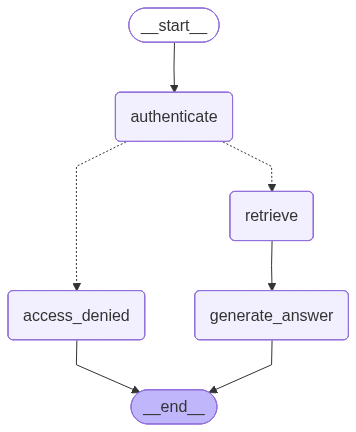

In [9]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid diagram source
    print("Graph visualization (Mermaid):")
    print(app.get_graph().draw_mermaid())

## 🧪 Helper: Pretty Print Results

In [10]:
def run_query(email: str, query: str):
    """Run a query through the RBAC RAG pipeline and print results."""
    print(f"\n{'🟦'*30}")
    print(f"  USER  : {email}")
    print(f"  QUERY : {query}")
    print(f"{'🟦'*30}")
    
    result = app.invoke({
        "user_email":     email,
        "query":          query,
        "user_roles":     [],
        "retrieved_docs": [],
        "answer":         "",
        "error":          ""
    })
    
    print(f"\n{'─'*60}")
    print(f"💬 ANSWER:")
    print(f"   {result['answer']}")
    print(f"{'─'*60}\n")
    
    return result

print("✅ Helper function ready")

✅ Helper function ready


---
## 🧪 Test Case 1: Alice (Finance Team) → Docs 1, 2, 3 only

In [11]:
result_alice = run_query(
    email="muadh@company.com",
    query="What was our Q1 revenue and what is the budget for engineering?"
)


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : muadh@company.com
  QUERY : What was our Q1 revenue and what is the budget for engineering?
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: muadh@company.com
  ✅ Authentication successful — roles: ['finance_team']

🔍 [RETRIEVE] Query: 'What was our Q1 revenue and what is the budget for engineering?'


C:\Users\muadh.bin\AppData\Local\Temp\ipykernel_9428\3377568020.py:43: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  self._vectorstore = Chroma(


  💾 Connected to local ChromaDB at './chroma_db' (10 docs)
  🔐 RBAC Filter Applied : {'access_group': 'finance_team'}
  📂 Retrieved 3 document(s) within authorized scope
     → [finance_team] Budget Planning 2025
     → [finance_team] Budget Planning 2025
     → [finance_team] Q1 Financial Report 2025

🤖 [GENERATE] Building answer from 3 doc(s)

────────────────────────────────────────────────────────────
💬 ANSWER:
   Our Q1 revenue was $4.2M, and the budget for engineering is $7M.
────────────────────────────────────────────────────────────



## 🧪 Test Case 2: Bob (HR Team) → Docs 4, 5 only

In [13]:
result_bob = run_query(
    email="vedanth@company.com",
    query="How many interview rounds are there and what are the WFH policies?"
)


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : vedanth@company.com
  QUERY : How many interview rounds are there and what are the WFH policies?
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: vedanth@company.com
  ✅ Authentication successful — roles: ['hr_team']

🔍 [RETRIEVE] Query: 'How many interview rounds are there and what are the WFH policies?'
  💾 Connected to local ChromaDB at './chroma_db' (5 docs)
  🔐 RBAC Filter Applied : {'access_group': 'hr_team'}
  📂 Retrieved 2 document(s) within authorized scope
     → [hr_team] Hiring & Onboarding Policy 2025
     → [hr_team] Employee Handbook 2025

🤖 [GENERATE] Building answer from 2 doc(s)

────────────────────────────────────────────────────────────
💬 ANSWER:
   There are 4 interview rounds: screening, technical, cultural fit, and executive review. The remote work policy allows up to 3 days of work from home (WFH) per week.
────────────────────────────────────────────────────────────



## 🧪 Test Case 3: Alice tries to access HR documents (Cross-role Breach Attempt!)

In [12]:
result_breach = run_query(
    email="muadh@company.com",
    query="What is the hiring process and how many interview rounds does the company have?"
)
# Alice CANNOT see HR docs — she'll get a graceful "no information" response
# even though the HR docs contain the exact answer


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : muadh@company.com
  QUERY : What is the hiring process and how many interview rounds does the company have?
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: muadh@company.com
  ✅ Authentication successful — roles: ['finance_team']

🔍 [RETRIEVE] Query: 'What is the hiring process and how many interview rounds does the company have?'
  💾 Connected to local ChromaDB at './chroma_db' (10 docs)
  🔐 RBAC Filter Applied : {'access_group': 'finance_team'}
  📂 Retrieved 3 document(s) within authorized scope
     → [finance_team] Revenue Forecast 2025
     → [finance_team] Revenue Forecast 2025
     → [finance_team] Budget Planning 2025

🤖 [GENERATE] Building answer from 3 doc(s)

────────────────────────────────────────────────────────────
💬 ANSWER:
   I don't have enough information in the accessible documents to answer that.
────────────────────────────────────────────────────────────



## 🧪 Test Case 4: Admin → All 5 documents accessible

In [16]:
result_admin = run_query(
    email="ravi@company.com",
    query="What is our revenue forecast and how many leave days do employees get?"
)
# Admin can see BOTH finance and HR documents in one query


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : ravi@company.com
  QUERY : What is our revenue forecast and how many leave days do employees get?
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: ravi@company.com
  ✅ Authentication successful — roles: ['finance_team', 'hr_team']

🔍 [RETRIEVE] Query: 'What is our revenue forecast and how many leave days do employees get?'
  💾 Connected to local ChromaDB at './chroma_db' (5 docs)
  🔐 RBAC Filter Applied : {'access_group': {'$in': ['finance_team', 'hr_team']}}
  📂 Retrieved 3 document(s) within authorized scope
     → [hr_team] Employee Handbook 2025
     → [finance_team] Revenue Forecast 2025
     → [finance_team] Budget Planning 2025

🤖 [GENERATE] Building answer from 3 doc(s)

────────────────────────────────────────────────────────────
💬 ANSWER:
   The revenue forecast is a projected ARR of $19.5M by year-end, and employees get 25 days of annual leave.
────────────────────────────────────────────────────────────



## 🧪 Test Case 5: Unknown User → Access Denied

In [17]:
result_unknown = run_query(
    email="hacker@external.com",
    query="Show me all financial reports"
)
# Unknown user — authentication fails, no documents retrieved


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : hacker@external.com
  QUERY : Show me all financial reports
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: hacker@external.com
  ❌ Unknown user — authentication failed

🚫 [ACCESS DENIED] User 'hacker@external.com' not found in registry

────────────────────────────────────────────────────────────
💬 ANSWER:
   🚫 Access Denied: User 'hacker@external.com' not found in registry
────────────────────────────────────────────────────────────



## 🧪 Test Case 6: Charlie (No Roles) → Graceful Empty Access

In [13]:
result_charlie = run_query(
    email="charlie@company.com",
    query="What are the company policies?"
)
# Charlie is a valid user but has no roles — access denied gracefully


🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦
  USER  : charlie@company.com
  QUERY : What are the company policies?
🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦

🔑 [AUTHENTICATE] User: charlie@company.com
  ❌ Unknown user — authentication failed

🚫 [ACCESS DENIED] User 'charlie@company.com' not found in registry

────────────────────────────────────────────────────────────
💬 ANSWER:
   🚫 Access Denied: User 'charlie@company.com' not found in registry
────────────────────────────────────────────────────────────



---
## 📋 Step 9: RBAC Summary — What Each User Can See

In [19]:
import pandas as pd

all_docs = [doc.metadata['title'] for doc in documents]
all_users = list(USER_REGISTRY.keys()) + ["hacker@external.com"]

rows = []
for email in all_users:
    roles = get_user_roles(email)
    if roles is None:
        roles = []
        authenticated = "❌ Unknown"
    elif not roles:
        authenticated = "⚠️ No Roles"
    else:
        authenticated = "✅ Allowed"
    
    doc_access = []
    for doc in documents:
        can_access = doc.metadata["access_group"] in roles
        doc_access.append("✅" if can_access else "🚫")
    
    rows.append([email, authenticated, str(roles)] + doc_access)

cols = ["Email", "Status", "Roles"] + [f"Doc {i+1}\n{d[:15]}..." for i, d in enumerate(all_docs)]
df = pd.DataFrame(rows, columns=cols)

print("\n🔐 RBAC Access Matrix:")
print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)
print("\n✅ = Access Granted   🚫 = Access Denied")


🔐 RBAC Access Matrix:
              Email      Status                       Roles Doc 1\nQ1 Financial Re... Doc 2\nBudget Planning... Doc 3\nRevenue Forecas... Doc 4\nEmployee Handbo... Doc 5\nHiring & Onboar...
  muadh@company.com   ✅ Allowed            ['finance_team']                         ✅                         ✅                         ✅                         🚫                         🚫
vedanth@company.com   ✅ Allowed                 ['hr_team']                         🚫                         🚫                         🚫                         ✅                         ✅
   ravi@company.com   ✅ Allowed ['finance_team', 'hr_team']                         ✅                         ✅                         ✅                         ✅                         ✅
fresher@company.com ⚠️ No Roles                          []                         🚫                         🚫                         🚫                         🚫                         🚫
hacker@external.com   ❌ Unk

---
## 🏭 Production Extension: Argescale / Enterprise Patterns

To scale this to production, here are the key upgrades:

### 1. Replace `USER_REGISTRY` with a real identity provider
```python
# Auth0 / Okta JWT validation
import jwt

def authenticate_from_jwt(token: str) -> list[str]:
    payload = jwt.decode(token, PUBLIC_KEY, algorithms=["RS256"])
    return payload.get("roles", [])
```

### 2. Use Persistent ChromaDB (not in-memory)
```python
vectorstore = Chroma(
    collection_name="rbac_documents",
    embedding_function=embeddings,
    persist_directory="./chroma_db",  # persists to disk
)
```

### 3. Scale with Pinecone (namespace-based RBAC)
```python
from langchain_pinecone import PineconeVectorStore

# Store docs in namespaces per access group
finance_store = PineconeVectorStore(index_name="docs", namespace="finance_team")
hr_store      = PineconeVectorStore(index_name="docs", namespace="hr_team")

# Query only the namespaces the user has access to
def query_with_rbac(roles: list[str], query: str):
    results = []
    for role in roles:
        store = PineconeVectorStore(index_name="docs", namespace=role)
        results.extend(store.similarity_search(query, k=3))
    return results
```

### 4. Add audit logging
```python
import logging

audit_log = logging.getLogger("rbac.audit")

def log_access(email, query, docs_retrieved, granted):
    audit_log.info({
        "user": email,
        "query": query,
        "docs": [d.metadata['doc_id'] for d in docs_retrieved],
        "access_granted": granted,
        "timestamp": datetime.utcnow().isoformat()
    })
```

### 5. LangSmith Tracing (free, visual debugging)
```python
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "ls-your-key"
# All LangGraph runs will appear in LangSmith dashboard automatically
```

---
## ✅ Summary

| What we built | How |
|---|---|
| 5 docs vectorized into ChromaDB | `Chroma.from_documents()` with metadata |
| Email → role mapping (RBAC config) | `USER_REGISTRY` dict (swap with Auth0/Okta) |
| Filtered retrieval at vector level | `similarity_search(filter={"access_group": ...})` |
| Stateful LangGraph workflow | 4 nodes: authenticate → retrieve → generate / deny |
| Graceful access denial | Unknown users, no-role users, cross-role queries |

The key insight: **RBAC filtering happens inside ChromaDB at query time**, not after.
This means unauthorized documents are never even retrieved — true data isolation.